# Perfil de Qualificação da Audiência

Esse notebook constroe um score de qualificação da audiência para cada perfil, baseado em duas dimensões comportamentais observáveis: nível de engajamento típico e estabilidade do engajamento ao longo do tempo.

## Definição operacional

A qualificação da audiência é tratada como um representante relativo ao segmento do perfil.
O score não mede demografia, autenticidade direta de seguidores ou variáveis latentes de qualidade.
Trata-se de um indicador de posicionamento relativo ao segmento (`inf_category × bucket_followers`),
o que torna a comparação metodologicamente justa entre perfis de porte e nicho semelhantes.


1. **Nível de engajamento típico** (mediana do ER clássico do perfil);
2. **Estabilidade do engajamento** (coeficiente de variação invertido).

## Dimensões do score

| Dimensão | Indicador | Direção | Peso |
|---|---|---|---|
| Engajamento típico | Mediana do ER clássico do perfil | ↑ maior = melhor | 0,60 |
| Estabilidade | CV do ER | ↓ menor CV = melhor | 0,40 |

Na seção 07 há uma análise de sensibilidade dos pesos(0,60/0,40).

## Normalização por segmento

Cada dimensão é normalizada como rank percentil dentro do segmento, de modo que um perfil de fashion nano so é comparado com outros perfis de fashion nano, cujo ER estrutural são similares.

## 1. Configuração

In [2]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

pl.Config.set_tbl_rows(10)
pl.Config.set_fmt_str_lengths(60)
sns.set_theme(style="whitegrid", context="talk")

In [3]:
# Caminhos
DIRETORIO = Path("bases-processadas/")

PARQUET_BASE = f"{DIRETORIO}/posts_base_2017_2019.parquet"
PARQUET_CV = f"{DIRETORIO}/cv_base_2017_2019.parquet"   
PARQUET_CV_ROB = f"{DIRETORIO}/cv_core_2017_2019.parquet"   

OUT_PARQUET = f"{DIRETORIO}/perfil_qualificacao.parquet"
OUT_CSV = f"{DIRETORIO}/perfil_qualificacao.csv"

ORDEM_BUCKET = ["nano", "micro", "mid-tier", "macro", "mega"]
ORDEM_TIER = ["D", "C", "B", "A"]

# Pesos do score
W_ER = 0.60
W_CV = 0.40

## 2. Carga e Verificação das bases

| Base | Descrição |
|---|---|
| `posts_base_2017_2019` | Base analítica principal — nível de post, 2017–2019, followers > 0 |
| `cv_base_2017_2019` | CV do ER clássico por perfil — calculado sobre todos os posts válidos (**base principal**) |
| `cv_core_2017_2019` | CV calculado apenas sobre posts com `comments_count > 0` — usado na verificação de robustez |


In [4]:
base   = pl.read_parquet(PARQUET_BASE)
cvbase = pl.read_parquet(PARQUET_CV)
# cvcore = pl.read_parquet(PARQUET_CV_ROB)

print(f"Base principal:{base.shape}")
print(f"CV base:{cvbase.shape}")
# print(f"CV core: {cvcore.shape}")

Base principal:(8897233, 32)
CV base:(33127, 6)


## 3. Agregação em nível de perfil

Cada perfil é resumido pela mediana do ER classico. A média é mantida como métrica de auxiliar.

In [5]:
perfis = (
    base.group_by("username")
    .agg([
        pl.len().alias("n_posts_total"),
        pl.col("followers").median().alias("followers"),
        pl.col("inf_category").first().alias("inf_category"),
        pl.col("bucket_followers").first().alias("bucket_followers"),
        pl.col("perfil_completo_lookup").first().alias("perfil_completo_lookup"),
        pl.col("er_classico").median().alias("erclassico_mediana"),
        pl.col("er_classico").mean().alias("erclassico_media"),
        pl.col("er_weighted").median().alias("erweighted_mediana"),
        pl.col("is_sponsored").mean().alias("is_sponsored_pct"),
        (pl.col("post_type") == "image").mean().alias("pct_image"),
        (pl.col("post_type") == "carousel").mean().alias("pct_carousel"),
    ])
)


In [6]:
perfis = perfis.join(cvbase.select(["username", "n_posts_validos", "er_media", "er_mediana", "cv"]),on="username", how="left")

In [7]:
perfis

username,n_posts_total,followers,inf_category,bucket_followers,perfil_completo_lookup,erclassico_mediana,erclassico_media,erweighted_mediana,is_sponsored_pct,pct_image,pct_carousel,n_posts_validos,er_media,er_mediana,cv
str,u32,f64,str,str,bool,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64
"""ashleyagodfrey""",300,1441.0,"""fashion""","""nano""",true,8.32755,8.524867,8.32755,0.01,0.973333,0.026667,300,8.524867,8.32755,0.27679
"""hkcung""",300,59975.0,"""fashion""","""micro""",true,2.478533,2.661787,2.488537,0.166667,0.753333,0.246667,300,2.661787,2.478533,0.323615
"""ralphw78""",300,1003.0,"""other""","""nano""",true,6.63011,7.399468,6.63011,0.096667,0.736667,0.263333,300,7.399468,6.63011,0.522028
"""sea_see_you""",296,157496.0,"""fashion""","""mid-tier""",true,4.088358,4.129528,4.09312,0.0,0.746622,0.253378,296,4.129528,4.088358,0.084652
"""teodoravidak""",295,4777.0,"""fashion""","""nano""",true,3.663387,4.583758,3.663387,0.016949,0.911864,0.088136,295,4.583758,3.663387,0.674906
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""khris_bajis""",299,24137.0,"""fashion""","""micro""",true,8.67962,8.371125,8.67962,0.026756,0.926421,0.073579,299,8.371125,8.67962,0.339245
"""s.jones.fitness""",300,97919.0,"""fitness""","""micro""",true,1.040656,1.031638,1.040656,0.02,0.523333,0.476667,300,1.031638,1.040656,0.07409
"""stephwithph""",110,14430.0,"""food""","""micro""",true,2.408177,2.80533,2.408177,0.127273,0.972727,0.027273,110,2.80533,2.408177,0.505242


## 4. Critérios de Elegibilidade

Um perfil precisa satisfazer todos os critérios abaixo para entrar no cálculo do score.
Perfis inelegíveis são preservados na base final com `elegivel = False` e `score_audiencia = null`,
garantindo rastreabilidade.

| Critério | Limiar | Justificativa |
|---|---|---|
| Posts totais | ≥ 30 | Garantia de representatividade temporal do perfil no período |
| Posts válidos no CV | ≥ 10 | Mínimo para estimativa estável do coeficiente de variação |
| Lookup completo | `perfil_completo_lookup == True` | Perfis sem dados do lookup têm followers = 0 |
| Categoria e bucket presentes | não nulo | Necessário para normalização por segmento |

In [8]:
total = perfis.shape[0]
sem_cv           = perfis.filter(pl.col("cv").is_null()).shape[0]
menos_10_validos = perfis.filter(pl.col("n_posts_validos") < 10).shape[0]
menos_30_posts = perfis.filter(pl.col("n_posts_total") < 30).shape[0]
lookup_inc       = perfis.filter(pl.col("perfil_completo_lookup") == False).shape[0]
cat_nula         = perfis.filter(pl.col("inf_category").is_null()).shape[0]
bucket_nulo      = perfis.filter(pl.col("bucket_followers").is_null()).shape[0]

In [9]:
inelegivel = perfis.filter(
    (pl.col("n_posts_total") < 30) |
    (pl.col("n_posts_validos") < 10) |
    (pl.col("perfil_completo_lookup") == False) |
    pl.col("inf_category").is_null() |
    pl.col("bucket_followers").is_null() |
    pl.col("cv").is_null()
).shape[0]

In [10]:
print("Diagnostico dos perfis: ")

print(f"Total de perfis: {total}")
print(f"Menos de 30 posts: {menos_30_posts}")
print(f"Menos de 10 posts válidos para CV: {menos_10_validos}")
print(f"Lookup Incompleto: {lookup_inc}")
print(f"Categoria incompleta: {cat_nula}")
print(f"Bucket Ausente: {bucket_nulo}")
print(f"CV Ausente: {sem_cv}")
print(f"Total de perfis não elegiveis: {inelegivel}")

Diagnostico dos perfis: 
Total de perfis: 33149
Menos de 30 posts: 140
Menos de 10 posts válidos para CV: 24
Lookup Incompleto: 0
Categoria incompleta: 0
Bucket Ausente: 0
CV Ausente: 22
Total de perfis não elegiveis: 140


- Aplicar uma flag de elegibilidade

In [11]:
perfis = perfis.with_columns(
    pl.when(
        (pl.col("n_posts_total") >= 30) &
        (pl.col("n_posts_validos") >= 10) &
        (pl.col("perfil_completo_lookup") == True) &
        pl.col("inf_category").is_not_null() &
        pl.col("bucket_followers").is_not_null() &
        pl.col("cv").is_not_null()
    ).then(True).otherwise(False).alias("elegivel")
)

elegiveis = perfis.filter(pl.col("elegivel") == True)
print(f"Perfis elegíveis:   {elegiveis.shape[0]}")
print(f"Perfis inelegíveis: {perfis.filter(pl.col('elegivel') == False).shape[0]}")

Perfis elegíveis:   33009
Perfis inelegíveis: 140


## 5. Construção do Score de qualificação

Para cada perfil elegível, calcula-se o rank percentil de er_mediana e de cv dentro do seu segmento (categoria x bucket de followers)

O rank percentil \( p_i \) de um perfil \( i \) dentro do segmento \( s \) é definido como:

$
p_i = \frac{\text{rank}(x_i) - 1}{N_s - 1}
$

onde \( N_s \) é o número de perfis elegíveis no segmento e $( \text{rank}(x_i) )$ é a posição
ordinal de \( i \) (1 = menor valor).

O score final é então:

$
\text{score}_i = W_{ER} \cdot p_{ER,i} + W_{CV} \cdot (1 - p_{CV,i})
$

onde $( W_{ER} = 0{,}60 )$ e $( W_{CV} = 0{,}40 )$. O CV é invertido porque menor CV
(maior estabilidade) é desejável.


In [12]:
elegiveis_pd = elegiveis.to_pandas()

In [13]:
def rank_percentil(series):
    n = len(series)
    if n == 1:
        return pd.Series([0.5], index=series.index)
    return series.rank(method="average").sub(1).div(n - 1)

In [14]:
elegiveis_pd["rank_er"] = (
    elegiveis_pd.groupby(["inf_category", "bucket_followers"])["erclassico_mediana"]
    .transform(rank_percentil)
)
elegiveis_pd["rank_cv"] = (
    elegiveis_pd.groupby(["inf_category", "bucket_followers"])["cv"]
    .transform(rank_percentil)
)

- Score final

In [15]:
elegiveis_pd["score_audiencia"] = (
    W_ER * elegiveis_pd["rank_er"] +
    W_CV * (1 - elegiveis_pd["rank_cv"])
)

In [16]:
elegiveis_pd.sort_values("score_audiencia",ascending=False)

,username,n_posts_total,followers,inf_category,bucket_followers,perfil_completo_lookup,erclassico_mediana,erclassico_media,erweighted_mediana,is_sponsored_pct,pct_image,pct_carousel,n_posts_validos,er_media,er_mediana,cv,elegivel,rank_er,rank_cv,score_audiencia
9899,foodiemuggles,298,4252.0,food,nano,True,36.876764,36.600857,36.935560,0.033557,0.409396,0.590604,298,36.600857,36.876764,0.135477,True,1.000000,0.000000,1.000000
17890,itsdougthepug,299,3642341.0,pet,mega,True,3.142704,3.310001,3.142704,0.020067,0.923077,0.076923,299,3.310001,3.142704,0.304496,True,1.000000,0.000000,1.000000
8554,nico.sunshine.50,299,1377.0,travel,nano,True,26.579521,26.738608,26.652142,0.000000,1.000000,0.000000,299,26.738608,26.579521,0.129958,True,0.998250,0.001167,0.998483
6876,dailysurfgr,254,3408.0,other,nano,True,23.474178,23.038081,23.474178,0.007874,0.818898,0.181102,254,23.038081,23.474178,0.139913,True,0.997543,0.000351,0.998385
12630,boulderlocavore,299,29484.0,food,micro,True,18.677927,19.473722,18.708452,0.013378,1.000000,0.000000,299,19.473722,18.677927,0.133788,True,1.000000,0.004632,0.998147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22961,thestylejournal_,300,166317.0,fashion,mid-tier,True,0.065838,0.247706,0.065838,0.020000,0.810000,0.190000,300,0.247706,0.065838,2.304746,True,0.000557,0.998886,0.000780
75,peachyqueenblog,294,1349883.0,beauty,mega,True,0.099972,0.176874,0.099972,0.000000,0.755102,0.244898,294,0.176874,0.099972,1.537523,True,0.000000,1.000000,0.000000
26325,dogsofinstagram,300,4284911.0,pet,mega,True,0.960288,1.073313,0.960288,0.036667,0.873333,0.126667,300,1.073313,0.960288,0.509256,True,0.000000,1.000000,0.000000
14385,paperazzimagazine,300,588477.0,fashion,macro,True,0.021666,0.063588,0.021666,0.000000,0.726667,0.273333,300,0.063588,0.021666,2.259413,True,0.000000,1.000000,0.000000


- Cobertura dos segmentos

In [17]:
cobertura = (
    elegiveis_pd.groupby(["inf_category", "bucket_followers"])
    .size()
    .reset_index(name="n_perfis")
    .pivot(index="inf_category", columns="bucket_followers", values="n_perfis")
)
cobertura = cobertura[[b for b in ORDEM_BUCKET if b in cobertura.columns]].fillna(0).astype(int)
cobertura

bucket_followers,nano,micro,mid-tier,macro,mega
inf_category,,,,,
beauty,524,693,210,34,37
family,1806,1596,368,76,101
fashion,3050,6103,1796,324,353
fitness,285,562,188,24,37
food,1460,1728,252,25,6
interior,363,676,115,13,7
other,2850,1821,575,118,164
pet,156,324,80,6,4
travel,1715,1908,402,47,27


## 6. Classiciação em Tiers

Os perfis elegiveis são então classificados em 4 tiers(A,B,C e D) com base em quartis do score, calculados globalmente após normalização por segmento.

| Tier | Quartil | Interpretação |
|---|---|---|
| A | Q4 (75–100%) | Alta qualificação - engajamento elevado e estável no segmento |
| B | Q3 (50–75%) | Qualificação moderada-alta |
| C | Q2 (25–50%) | Qualificação moderada-baixa |
| D | Q1 (0–25%) | Baixa qualificação - engajamento baixo ou instável |


- classificação em tiers por quartil do score

In [18]:
elegiveis_pd["tier_audiencia"] = pd.qcut(
    elegiveis_pd["score_audiencia"],
    q=4,
    labels=["D", "C", "B", "A"]
)

In [19]:
tier_dist = (
    elegiveis_pd.groupby("tier_audiencia", observed=True)
    .size()
    .reset_index(name="n_perfis")
)
tier_dist["pct"] = (tier_dist["n_perfis"] / tier_dist["n_perfis"].sum() * 100).round(2)
tier_dist

,tier_audiencia,n_perfis,pct
0,D,8253,25.0
1,C,8252,25.0
2,B,8252,25.0
3,A,8252,25.0


- Perfil descritivo dos tiers

In [20]:
tier_desc = (
    elegiveis_pd.groupby("tier_audiencia", observed=True)
    .agg(
        erclassico_mediana_mediana=("erclassico_mediana", "median"),
        cv_mediano=("cv", "median"),
        score_mediano=("score_audiencia", "median"),
        n_posts_total_mediano=("n_posts_total", "median"),
        is_sponsored_pct_mediana=("is_sponsored_pct", "median"),
    )
    .round(4)
)
tier_desc

,erclassico_mediana_mediana,cv_mediano,score_mediano,n_posts_total_mediano,is_sponsored_pct_mediana
tier_audiencia,,,,,
D,1.2740,0.7144,0.2000,299.0,0.0254
C,2.4692,0.5083,0.4177,299.0,0.0282
B,3.8621,0.4562,0.5925,299.0,0.0286
A,6.2985,0.3483,0.7924,298.0,0.0267


- Distribuição dos tiers por bucket de seguidores

In [21]:
tier_bucket = (
    elegiveis_pd.groupby(["bucket_followers", "tier_audiencia"], observed=True)
    .size()
    .reset_index(name="n")
    .pivot(index="bucket_followers", columns="tier_audiencia", values="n")
    .fillna(0).astype(int)
)
tier_bucket = tier_bucket.loc[[b for b in ORDEM_BUCKET if b in tier_bucket.index]]

In [22]:
tier_bucket_pct = tier_bucket.div(tier_bucket.sum(axis=1), axis=0).round(3)
tier_bucket_pct

tier_audiencia,D,C,B,A
bucket_followers,,,,
nano,0.254,0.254,0.241,0.251
micro,0.243,0.254,0.258,0.245
mid-tier,0.255,0.235,0.255,0.254
macro,0.271,0.210,0.238,0.280
mega,0.279,0.219,0.215,0.288


- Correlação entre score e dimensões componentes


In [23]:
corr_cols = ["score_audiencia", "erclassico_mediana", "erweighted_mediana", "cv"]
elegiveis_pd[corr_cols].corr().round(4)

,score_audiencia,erclassico_mediana,erweighted_mediana,cv
score_audiencia,1.0000,0.6852,0.685,-0.5113
erclassico_mediana,0.6852,1.0000,1.000,-0.2221
erweighted_mediana,0.6850,1.0000,1.000,-0.2220
cv,-0.5113,-0.2221,-0.222,1.0000


## 7. Análise de Sensibilidade dos pesos

Na ausência de uma ponderação teoricamente estabelecida na literatura, a escolha de
\( W_{ER} = 0{,}60 \) e \( W_{CV} = 0{,}40 \) é uma decisão do pesquisador. Para demonstrar
que os resultados não dependem criticamente dessa escolha, calcula-se o score para
três cenários de pesos e verifica-se:

1. A correlação de Spearman entre os rankings gerados por cada cenário.
2. A proporção de perfis que mantém o mesmo tier independentemente dos pesos.

Se a correlação entre rankings for > 0,95 e a estabilidade de tier for > 85%,
a classificação é considerada robusta à escolha de pesos

In [24]:
# Cenários de pesos para análise de sensibilidade
cenarios = {
    "40_60": (0.40, 0.60),  # CV dominante
    "50_50": (0.50, 0.50),  # Igualitário
    "60_40": (0.60, 0.40),  # cenário principal (Base)
    "70_30": (0.70, 0.30),  # TE dominante
}

scores_cenarios = pd.DataFrame({"username": elegiveis_pd["username"]})

for nome, (w_er, w_cv) in cenarios.items():
    scores_cenarios[f"score_{nome}"] = (
        w_er * elegiveis_pd["rank_er"] +
        w_cv * (1 - elegiveis_pd["rank_cv"])
    )
# Correlações de Spearman entre cenários
from itertools import combinations
print("Correlações de Spearman entre rankings por cenário de pesos:")
pares = list(combinations(cenarios.keys(), 2))
for a, b in pares:
    rho, _ = spearmanr(scores_cenarios[f"score_{a}"], scores_cenarios[f"score_{b}"])
    print(f"  {a} vs {b}: ρ = {rho:.4f}")

Correlações de Spearman entre rankings por cenário de pesos:
  40_60 vs 50_50: ρ = 0.9876
  40_60 vs 60_40: ρ = 0.9510
  40_60 vs 70_30: ρ = 0.8979
  50_50 vs 60_40: ρ = 0.9875
  50_50 vs 70_30: ρ = 0.9550
  60_40 vs 70_30: ρ = 0.9896


In [25]:
# Estabilidade de tier entre cenários
for nome, (w_er, w_cv) in cenarios.items():
    scores_cenarios[f"tier_{nome}"] = pd.qcut(
        scores_cenarios[f"score_{nome}"], q=4, labels=["D", "C", "B", "A"]
    )

# Proporção de perfis que mantém o mesmo tier em todos os cenários
tier_cols = [f"tier_{c}" for c in cenarios]
scores_cenarios["tier_estavel"] = scores_cenarios[tier_cols].apply(
    lambda row: len(set(row)) == 1, axis=1
)

pct_estavel = scores_cenarios["tier_estavel"].mean() * 100
print(f"Perfis com mesmo tier em todos os cenários: {pct_estavel:.2f}%")

# Distribuição de discordâncias
print(f"\nPerfis que mudam de tier:")
print(scores_cenarios[~scores_cenarios["tier_estavel"]][tier_cols].value_counts().head(10))

Perfis com mesmo tier em todos os cenários: 63.67%

Perfis que mudam de tier:
tier_40_60  tier_50_50  tier_60_40  tier_70_30
B           B           C           C             953
C           C           B           B             949
B           C           C           C             878
C           B           B           B             741
            C           C           B             718
A           A           A           B             680
B           B           B           C             674
A           A           B           B             614
B           B           A           A             607
            A           A           A             577
Name: count, dtype: int64


### Visualização da migração de tier entre cenários

Para além do percentual global de estabilidade, visualizamos:
1. **Matriz de transição** -> entre o cenário base (60/40) e cada cenário alternativo
2. **% de migração por tier** -> qual tier sofre mais reclassificação ao variar os pesos

In [59]:
tier_order = ["D", "C", "B", "A"]
base_col = "tier_60_40"  # cenário principal
alt_cenarios = {"40_60": "CV dom. (40/60)", "50_50": "Igualit. (50/50)", "70_30": "TE dom. (70/30)"}


- Matriz de transição (heatmap) para cada cenário alternativo

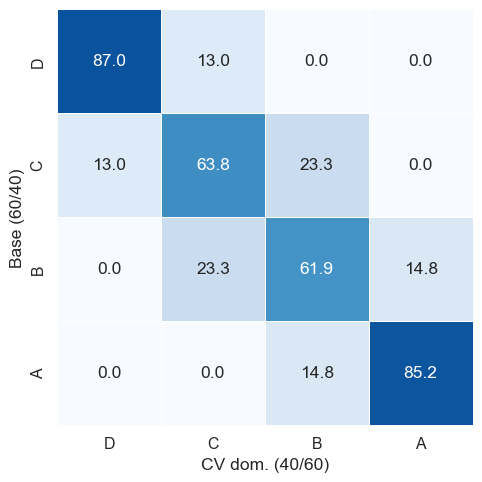

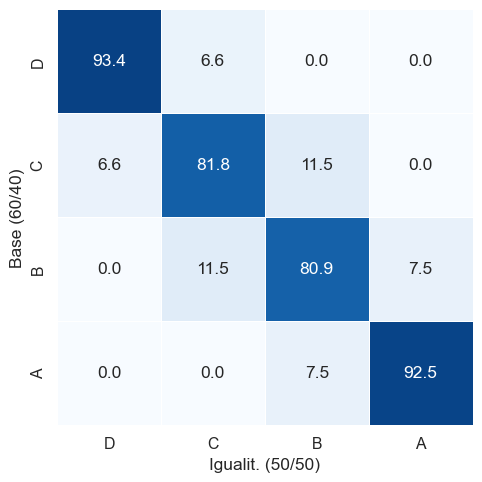

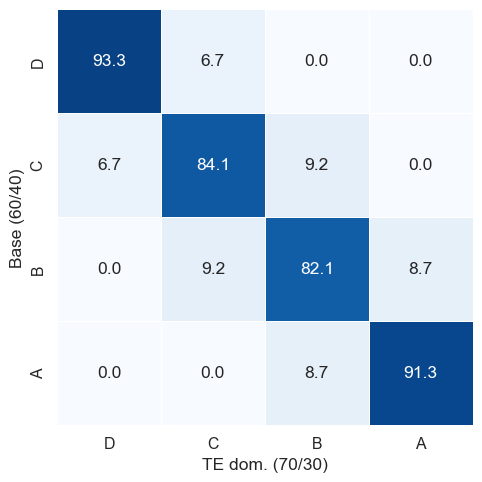

In [60]:
for cen, label in alt_cenarios.items():
    alt_col = f"tier_{cen}"

    ct = pd.crosstab(
        scores_cenarios[base_col],
        scores_cenarios[alt_col],
        normalize="index"
    ).reindex(
        index=tier_order,
        columns=tier_order,
        fill_value=0
    ) * 100

    plt.figure(figsize=(5, 5))

    sns.heatmap(
        ct,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        vmin=0,
        vmax=100,
        cbar=False,
        linewidths=0.5,
        linecolor="white"
    )

    plt.xlabel(label)
    plt.ylabel("Base (60/40)")
    plt.tight_layout()

    plt.savefig(
        f"output/fig_migracao_tier_{cen}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [61]:
alt_cenarios = {
    "40_60": "CV-Dominant (40/60)",
    "50_50": "Equal Weights (50/50)",
    "70_30": "ER-Dominant (70/30)",
}

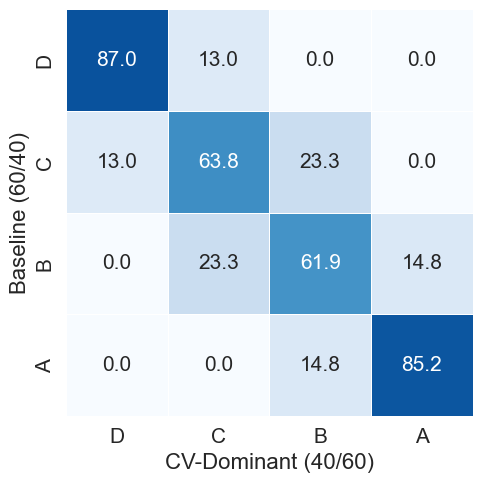

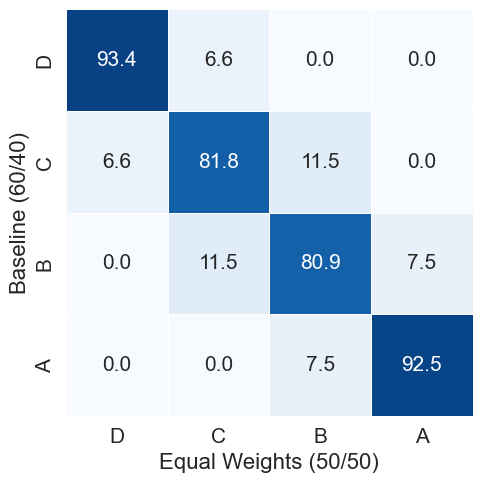

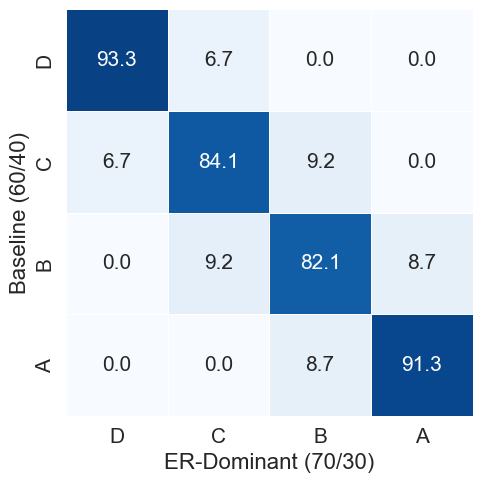

In [65]:
for cen, label in alt_cenarios.items():
    alt_col = f"tier_{cen}"

    ct = pd.crosstab(
        scores_cenarios[base_col],
        scores_cenarios[alt_col],
        normalize="index"
    ).reindex(
        index=tier_order,
        columns=tier_order,
        fill_value=0
    ) * 100

    plt.figure(figsize=(5, 5))

    ax = sns.heatmap(
        ct,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        vmin=0,
        vmax=100,
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        annot_kws={"fontsize": 15}      # valores nas células
    )

    ax.set_xlabel(label, fontsize=16)
    ax.set_ylabel("Baseline (60/40)", fontsize=16)

    ax.tick_params(axis="x", labelsize=15)
    ax.tick_params(axis="y", labelsize=15)

    plt.tight_layout()

    plt.savefig(
        f"output/fig_tier_transition_{cen}_en.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

- Gráfico de barras: % de perfis que migraram de tier, por tier original

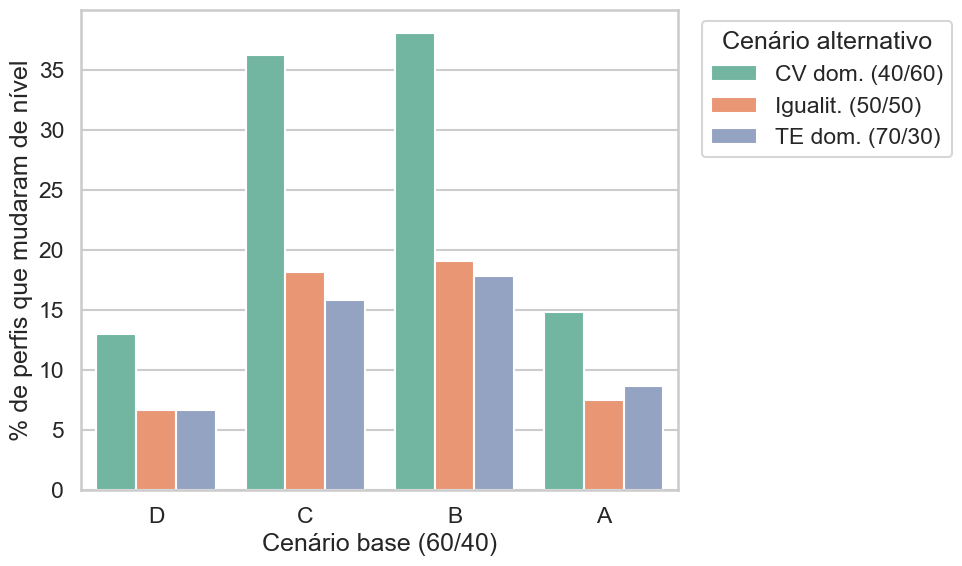

In [29]:
migra_por_tier = []
for cen, label in alt_cenarios.items():
    alt_col = f"tier_{cen}"
    for tier in tier_order:
        mask = scores_cenarios[base_col] == tier
        n_total = mask.sum()
        n_migrou = (scores_cenarios.loc[mask, alt_col] != tier).sum()
        pct = (n_migrou / n_total * 100) if n_total > 0 else 0
        migra_por_tier.append({"Cenário": label, "Tier base": tier, "% Migração": pct})

df_migra = pd.DataFrame(migra_por_tier)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df_migra, x="Tier base", y="% Migração", hue="Cenário",
    order=tier_order, ax=ax, palette="Set2"
)
# ax.set_title("Percentual de perfis que migraram de tier por cenário alternativo")
ax.set_xlabel("Cenário base (60/40)")
ax.set_ylabel("% de perfis que mudaram de nível")
ax.legend(title="Cenário alternativo", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("output/fig_migracao_tier_barras.png", dpi=150, bbox_inches="tight")
plt.show()


In [30]:
print("RESUMO DA MIGRAÇÃO DE TIER")
print(f"Perfis com tier estável em todos os cenários: {pct_estavel:.1f}%")
print(f"Perfis que migram em pelo menos um cenário:   {100 - pct_estavel:.1f}%")
print()
for cen, label in alt_cenarios.items():
    alt_col = f"tier_{cen}"
    pct_migra = (scores_cenarios[base_col] != scores_cenarios[alt_col]).mean() * 100
    print(f"  Base → {label}: {pct_migra:.1f}% migraram")

RESUMO DA MIGRAÇÃO DE TIER
Perfis com tier estável em todos os cenários: 63.7%
Perfis que migram em pelo menos um cenário:   36.3%

  Base → CV dom. (40/60): 25.5% migraram
  Base → Igualit. (50/50): 12.9% migraram
  Base → TE dom. (70/30): 12.3% migraram


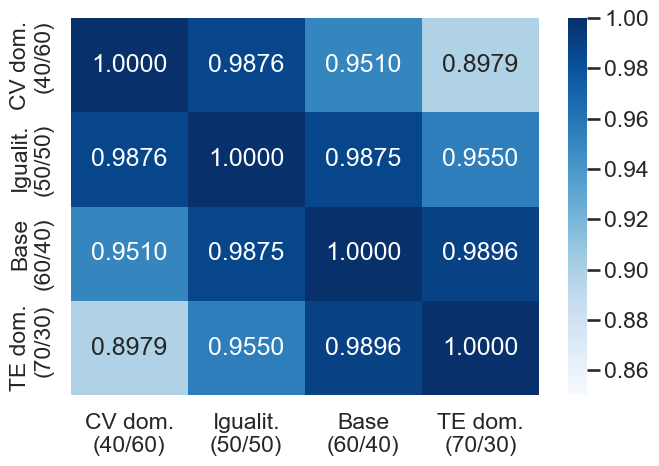

In [31]:
cenarios = {
    "4060": (0.40, 0.60),
    "5050": (0.50, 0.50),
    "6040": (0.60, 0.40),
    "7030": (0.70, 0.30),
}
labels = {"4060": "CV dom.\n(40/60)", "5050": "Igualit.\n(50/50)",
          "6040": "Base\n(60/40)", "7030": "TE dom.\n(70/30)"}

scorecenarios = pd.DataFrame({"username": elegiveis_pd["username"]})
for nome, (wer, wcv) in cenarios.items():
    scorecenarios[f"score_{nome}"] = wer * elegiveis_pd["rank_er"] + wcv * (1 - elegiveis_pd["rank_cv"])

nomes = list(cenarios.keys())
mat = np.ones((len(nomes), len(nomes)))
for i, a in enumerate(nomes):
    for j, b in enumerate(nomes):
        if i != j:
            rho, _ = spearmanr(scorecenarios[f"score_{a}"], scorecenarios[f"score_{b}"])
            mat[i, j] = round(rho, 4)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pd.DataFrame(mat, index=[labels[n] for n in nomes], columns=[labels[n] for n in nomes]),
    annot=True, fmt=".4f", cmap="Blues", vmin=0.85, vmax=1.0, ax=ax
)
# ax.set_title("Correlações de Spearman entre cenários de pesos\n(análise de sensibilidade)")
plt.tight_layout()
plt.savefig("output/fig_sensibilidade_spearman.png", dpi=150)

## 8. Persistencia da base final

- Montar base final. Perfis inelegiveis tem score/tier nulos

In [32]:
inelegiveis_pd = perfis.filter(pl.col("elegivel") == False).to_pandas()
inelegiveis_pd["rank_er"]        = np.nan
inelegiveis_pd["rank_cv"]        = np.nan
inelegiveis_pd["score_audiencia"] = np.nan
inelegiveis_pd["tier_audiencia"]  = np.nan

In [33]:
colunas_finais = list(inelegiveis_pd.columns)
elegiveis_export = elegiveis_pd[[c for c in colunas_finais if c in elegiveis_pd.columns]].copy()

In [34]:
base_final = pd.concat([elegiveis_export, inelegiveis_pd], ignore_index=True)

- Exportar

In [35]:
base_final_pl = pl.from_pandas(base_final)
base_final_pl.write_parquet(OUT_PARQUET)
base_final_pl.write_csv(OUT_CSV)

print(f"Exportado: {OUT_PARQUET}")
print(f"Exportado: {OUT_CSV}")

Exportado: bases-processadas/perfil_qualificacao.parquet
Exportado: bases-processadas/perfil_qualificacao.csv


## 9. Síntese dos resultados

# Cálculo Exemplo

- Cobertura dos segmentos

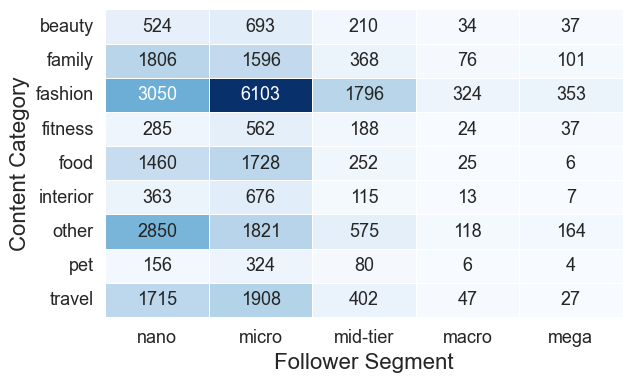

In [55]:
cobertura = (
    elegiveis.group_by("inf_category", "bucket_followers")
    .agg(pl.col("username").n_unique().alias("n_perfis"))
    .to_pandas()
    .pivot(index="inf_category", columns="bucket_followers", values="n_perfis")
    .fillna(0).astype(int)
)
cobertura = cobertura[[b for b in ORDEM_BUCKET if b in cobertura.columns]]

sns.set_context("paper", font_scale=1.3)
# fig, ax = plt.subplots(figsize=(10, 5))
fig, ax = plt.subplots(figsize=(6.5,4))

sns.heatmap(
    cobertura,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=.4,
    linecolor="white",
    cbar=False,
    annot_kws={"fontsize":13},
    ax=ax,
)

ax.set_xlabel("Follower Segment", fontsize=16)
ax.set_ylabel("Content Category", fontsize=16)
ax.tick_params(axis="x", labelrotation=0, labelsize=13)
ax.tick_params(axis="y", labelrotation=0, labelsize=13)

plt.tight_layout()
plt.savefig("output/fig_cobertura_segmentos_elegiveis_en.png", dpi=150)

- pt-br

In [44]:
traducao_categorias = {
    "beauty": "Beleza",
    "family": "Família",
    "fashion": "Moda",
    "fitness": "Fitness",
    "food": "Gastronomia",
    "interior": "Decoração",
    "pet": "Animais de Estimação",
    "travel": "Viagens",
    "other": "Outros"
}

traducao_segmentos = {
    "nano": "Nano",
    "micro": "Micro",
    "mid-tier": "Meso",
    "macro": "Macro",
    "mega": "Mega"
}

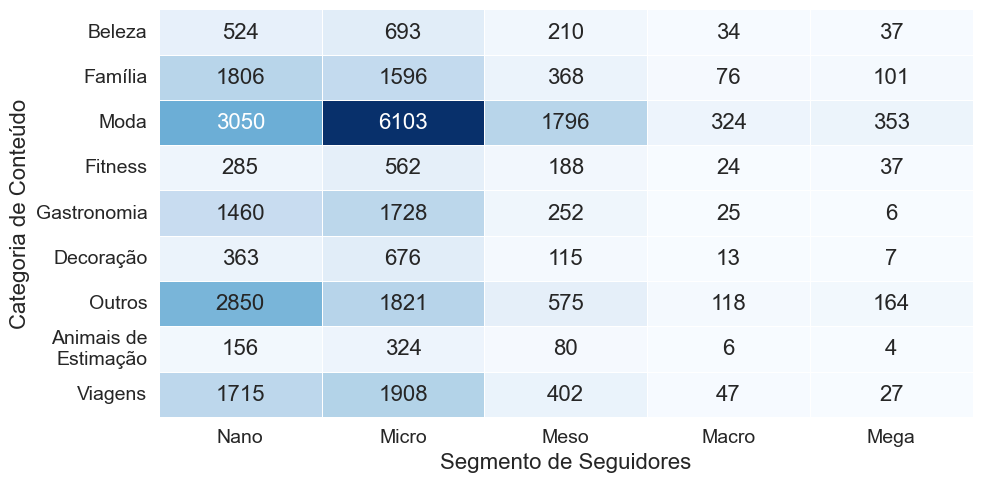

In [50]:
cobertura_plot = cobertura.rename(index=traducao_categorias)
cobertura_plot = cobertura_plot.rename(columns=traducao_segmentos)

# Aplicar quebra de linha nos índices longos
import textwrap

def wrap_labels(labels, width=12):
    return ['\n'.join(textwrap.wrap(label, width)) for label in labels]

fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    cobertura_plot,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    annot_kws={"fontsize": 16},
    linewidths=.5,
    linecolor="white",
    ax=ax
)

ax.set_xlabel("Segmento de Seguidores", fontsize=16)
ax.set_ylabel("Categoria de Conteúdo", fontsize=16)

ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

ax.set_yticklabels(
    wrap_labels([t.get_text() for t in ax.get_yticklabels()], width=16),
    rotation=0,
    va='center'
)

plt.tight_layout()
plt.savefig("output/fig_cobertura_segmentos_elegiveis.png", dpi=300)

In [65]:
perfil_A = (
    elegiveis_pd
    .query("tier_audiencia == 'A' and inf_category == 'fitness' and bucket_followers == 'micro'")
    .sort_values("score_audiencia", ascending=False)
    .iloc[35]
)

perfil_D = (
    elegiveis_pd
    .query("tier_audiencia == 'D' and inf_category == 'fitness' and bucket_followers == 'micro'")
    .sort_values("score_audiencia")
    .iloc[35]
)

for label, p in [("A", perfil_A), ("D", perfil_D)]:
    print(f"\n── Perfil nível {label} ──────────────────────")
    print(f"  Username     : @{p['username']}")
    print(f"  Seguidores   : {int(p['followers']):,}")
    print(f"  Categoria    : {p['inf_category']} × {p['bucket_followers']}")
    print(f"  Posts válidos: {int(p['n_posts_validos'])}")
    print(f"  Mediana TE   : {p['erclassico_mediana']:.4f}%")
    print(f"  CV           : {p['cv']:.4f}")
    print(f"  p_TE         : {p['rank_er']:.4f}")
    print(f"  p_CV         : {p['rank_cv']:.4f}")
    print(f"  Score        : {p['score_audiencia']:.4f}")
    print(f"  Nível        : {p['tier_audiencia']}")


── Perfil nível A ──────────────────────
  Username     : @eleonorasargenti
  Seguidores   : 17,390
  Categoria    : fitness × micro
  Posts válidos: 300
  Mediana TE   : 5.5607%
  CV           : 0.3144
  p_TE         : 0.8271
  p_CV         : 0.0891
  Score        : 0.8606
  Nível        : A

── Perfil nível D ──────────────────────
  Username     : @shauna_harrison
  Seguidores   : 86,040
  Categoria    : fitness × micro
  Posts válidos: 299
  Mediana TE   : 0.6625%
  CV           : 0.6466
  p_TE         : 0.0321
  p_CV         : 0.7166
  Score        : 0.1326
  Nível        : D


In [66]:
WER, WCV = 0.60, 0.40

for label, p in [("A", perfil_A), ("D", perfil_D)]:
    contribuicao_te = WER * p["rank_er"]
    contribuicao_cv = WCV * (1 - p["rank_cv"])
    score_calculado = contribuicao_te + contribuicao_cv

    print(f"\n{'='*55}")
    print(f"  PASSO A PASSO — @{p['username']}  (Nível {label})")
    print(f"{'='*55}")
    print(f"  Passo 1 - Mediana da TE      = {p['erclassico_mediana']:.4f}%")
    print(f"  Passo 2 - CV da TE           = {p['cv']:.4f}")
    print(f"  Passo 3 - Segmento           = {p['inf_category']} x {p['bucket_followers']}")
    seg = elegiveis_pd.query(
        f"inf_category == '{p['inf_category']}' and bucket_followers == '{p['bucket_followers']}'"
    )
    Ns = len(seg)
    print(f"           N_s no segmento     = {Ns} perfis")
    print(f"  Passo 4 - p_TE               = {p['rank_er']:.4f}  "
          f"(supera {p['rank_er']*100:.1f}% do segmento em TE)")
    print(f"           p_CV               = {p['rank_cv']:.4f}  "
          f"(supera {p['rank_cv']*100:.1f}% do segmento em CV)")
    print(f"  Passo 5 - 0,60 x {p['rank_er']:.4f}         = {contribuicao_te:.4f}")
    print(f"           0,40 x (1 - {p['rank_cv']:.4f}) = {contribuicao_cv:.4f}")
    print(f"           Score              = {score_calculado:.4f}")
    print(f"  Passo 6 - Nível             = {p['tier_audiencia']}")


  PASSO A PASSO — @eleonorasargenti  (Nível A)
  Passo 1 - Mediana da TE      = 5.5607%
  Passo 2 - CV da TE           = 0.3144
  Passo 3 - Segmento           = fitness x micro
           N_s no segmento     = 562 perfis
  Passo 4 - p_TE               = 0.8271  (supera 82.7% do segmento em TE)
           p_CV               = 0.0891  (supera 8.9% do segmento em CV)
  Passo 5 - 0,60 x 0.8271         = 0.4963
           0,40 x (1 - 0.0891) = 0.3643
           Score              = 0.8606
  Passo 6 - Nível             = A

  PASSO A PASSO — @shauna_harrison  (Nível D)
  Passo 1 - Mediana da TE      = 0.6625%
  Passo 2 - CV da TE           = 0.6466
  Passo 3 - Segmento           = fitness x micro
           N_s no segmento     = 562 perfis
  Passo 4 - p_TE               = 0.0321  (supera 3.2% do segmento em TE)
           p_CV               = 0.7166  (supera 71.7% do segmento em CV)
  Passo 5 - 0,60 x 0.0321         = 0.0193
           0,40 x (1 - 0.7166) = 0.1134
           Score          

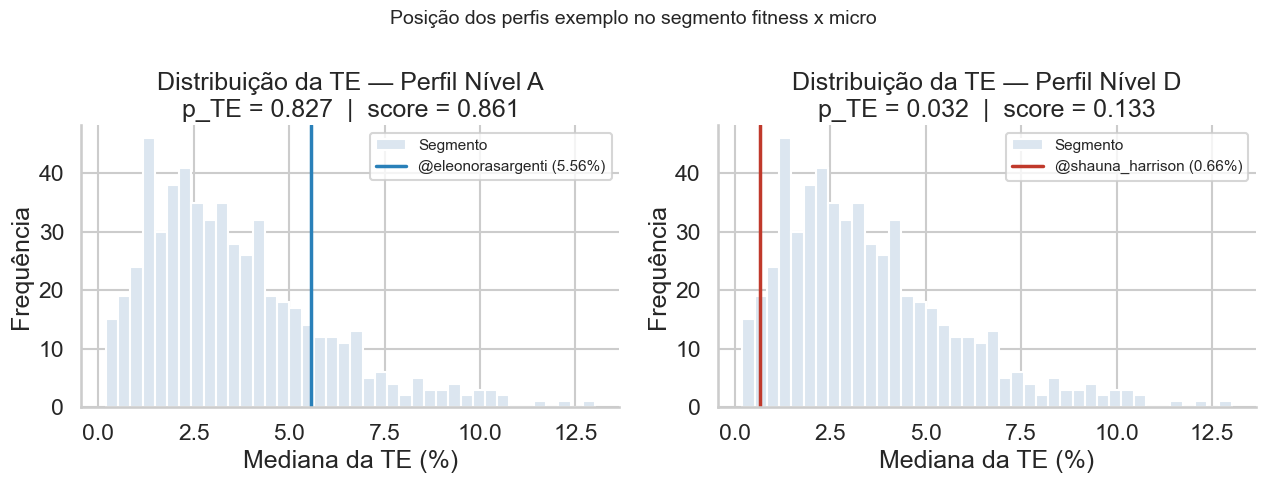

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Posição dos perfis exemplo no segmento fitness x micro", fontsize=14)

for ax, (label, p), cor in zip(axes,
                                [("A", perfil_A), ("D", perfil_D)],
                                ["#2980b9", "#c0392b"]):
    seg = elegiveis_pd.query(
        f"inf_category == '{p['inf_category']}' and bucket_followers == '{p['bucket_followers']}'"
    )

    ax.hist(seg["erclassico_mediana"], bins=40, color="#dce6f0", edgecolor="white", label="Segmento")
    ax.axvline(p["erclassico_mediana"], color=cor, linewidth=2.5,
               label=f"@{p['username']} ({p['erclassico_mediana']:.2f}%)")
    ax.set_title(f"Distribuição da TE — Perfil Nível {label}\n"
                 f"p_TE = {p['rank_er']:.3f}  |  score = {p['score_audiencia']:.3f}")
    ax.set_xlabel("Mediana da TE (%)")
    ax.set_ylabel("Frequência")
    ax.legend(fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("output/apendice_posicao_segmento.png", dpi=150, bbox_inches="tight")
plt.show()

In [68]:
p = perfil_D   
seg = elegiveis_pd.query(
    f"inf_category == '{p['inf_category']}' and bucket_followers == '{p['bucket_followers']}'"
)
Ns = len(seg)

# Posições ordinais reais
rank_te = int(round(p["rank_er"] * (Ns - 1) + 1))
rank_cv = int(round(p["rank_cv"] * (Ns - 1) + 1))

contrib_te = WER * p["rank_er"]
contrib_cv = WCV * (1 - p["rank_cv"])

faixas = {"A": "0,750 - 1,000", "B": "0,500 - 0,750",
          "C": "0,250 - 0,500", "D": "0,000 - 0,250"}
interp = {"A": "Alta qualificação — engajamento elevado e estável",
          "B": "Qualificação moderada-alta",
          "C": "Qualificação moderada-baixa",
          "D": "Baixo engajamento ou alta instabilidade"}

print(f"""
username              : {p['username']}
infcategory           : {p['inf_category']}
bucketfollowers       : {p['bucket_followers']}
followers             : {int(p['followers']):,}
npostsvalidos         : {int(p['n_posts_validos'])}
erclassicomediana     : {p['erclassico_mediana']:.4f}
cv                    : {p['cv']:.4f}
Ns                    : {Ns}
rank_te               : {rank_te}
rank_cv               : {rank_cv}
ranker (p_TE)         : {p['rank_er']:.4f}
rankcv (p_CV)         : {p['rank_cv']:.4f}
pct_te                : {p['rank_er']*100:.1f}
contrib_te            : {contrib_te:.4f}
contrib_cv            : {contrib_cv:.4f}
pct_contrib_te        : {contrib_te/p['score_audiencia']*100:.1f}
pct_contrib_cv        : {contrib_cv/p['score_audiencia']*100:.1f}
score                 : {p['score_audiencia']:.4f}
tier                  : {p['tier_audiencia']}
faixa_tier            : {faixas[p['tier_audiencia']]}
interpretacao_tier    : {interp[p['tier_audiencia']]}
""")


username              : shauna_harrison
infcategory           : fitness
bucketfollowers       : micro
followers             : 86,040
npostsvalidos         : 299
erclassicomediana     : 0.6625
cv                    : 0.6466
Ns                    : 562
rank_te               : 19
rank_cv               : 403
ranker (p_TE)         : 0.0321
rankcv (p_CV)         : 0.7166
pct_te                : 3.2
contrib_te            : 0.0193
contrib_cv            : 0.1134
pct_contrib_te        : 14.5
pct_contrib_cv        : 85.5
score                 : 0.1326
tier                  : D
faixa_tier            : 0,000 - 0,250
interpretacao_tier    : Baixo engajamento ou alta instabilidade



In [69]:
p = perfil_A  
seg = elegiveis_pd.query(
    f"inf_category == '{p['inf_category']}' and bucket_followers == '{p['bucket_followers']}'"
)
Ns = len(seg)

# Posições ordinais reais
rank_te = int(round(p["rank_er"] * (Ns - 1) + 1))
rank_cv = int(round(p["rank_cv"] * (Ns - 1) + 1))

contrib_te = WER * p["rank_er"]
contrib_cv = WCV * (1 - p["rank_cv"])

faixas = {"A": "0,750 - 1,000", "B": "0,500 - 0,750",
          "C": "0,250 - 0,500", "D": "0,000 - 0,250"}
interp = {"A": "Alta qualificação — engajamento elevado e estável",
          "B": "Qualificação moderada-alta",
          "C": "Qualificação moderada-baixa",
          "D": "Baixo engajamento ou alta instabilidade"}

print(f"""
username              : {p['username']}
infcategory           : {p['inf_category']}
bucketfollowers       : {p['bucket_followers']}
followers             : {int(p['followers']):,}
npostsvalidos         : {int(p['n_posts_validos'])}
erclassicomediana     : {p['erclassico_mediana']:.4f}
cv                    : {p['cv']:.4f}
Ns                    : {Ns}
rank_te               : {rank_te}
rank_cv               : {rank_cv}
ranker (p_TE)         : {p['rank_er']:.4f}
rankcv (p_CV)         : {p['rank_cv']:.4f}
pct_te                : {p['rank_er']*100:.1f}
contrib_te            : {contrib_te:.4f}
contrib_cv            : {contrib_cv:.4f}
pct_contrib_te        : {contrib_te/p['score_audiencia']*100:.1f}
pct_contrib_cv        : {contrib_cv/p['score_audiencia']*100:.1f}
score                 : {p['score_audiencia']:.4f}
tier                  : {p['tier_audiencia']}
faixa_tier            : {faixas[p['tier_audiencia']]}
interpretacao_tier    : {interp[p['tier_audiencia']]}
""")


username              : eleonorasargenti
infcategory           : fitness
bucketfollowers       : micro
followers             : 17,390
npostsvalidos         : 300
erclassicomediana     : 5.5607
cv                    : 0.3144
Ns                    : 562
rank_te               : 465
rank_cv               : 51
ranker (p_TE)         : 0.8271
rankcv (p_CV)         : 0.0891
pct_te                : 82.7
contrib_te            : 0.4963
contrib_cv            : 0.3643
pct_contrib_te        : 57.7
pct_contrib_cv        : 42.3
score                 : 0.8606
tier                  : A
faixa_tier            : 0,750 - 1,000
interpretacao_tier    : Alta qualificação — engajamento elevado e estável

